# MSDM 5053 Assignment 3

- **Name:** LAN, Tianwei  
- **Student ID:** 21230969  
- **Email:** tlanaa@connect.ust.hk

All tests use a 5% significance level. Following the assignment instruction, all ACF, Ljung-Box, and ARCH-effect checks use 10 lags.

## Question 1

First, we will load the data and convert the simple returns to percentage log returns.

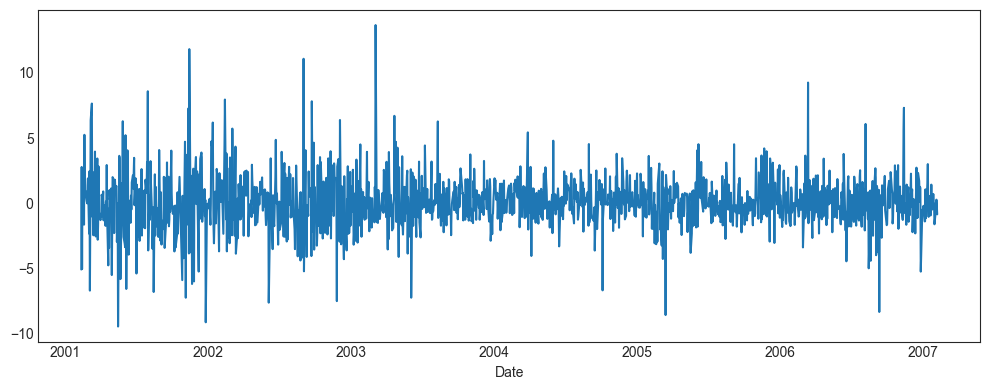

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch import arch_model

# Load data
df = pd.read_csv('d-sbuxsp0106.txt', header=None, sep=r'\s+', names=['Date', 'SBUX_rtn', 'SP_rtn'])
df['Date'] = pd.to_datetime(df['Date'].astype(str))
df.set_index('Date', inplace=True)

# Convert to percentage log returns
df['SBUX_log'] = 100 * np.log(1 + df['SBUX_rtn'])
df['SP_log'] = 100 * np.log(1 + df['SP_rtn'])

# Basic plot to verify
df['SBUX_log'].plot(figsize=(10, 4))
plt.xticks(rotation=0)

ax = plt.gca()
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.tick_params(direction='in', length=3, width=1)

plt.tight_layout()
plt.show()

### (a) Is there serial correlation in the log returns of Starbucks stock?

Ljung-Box test for SBUX log returns (10 lags):
      lb_stat  lb_pvalue
10  19.822642   0.030976


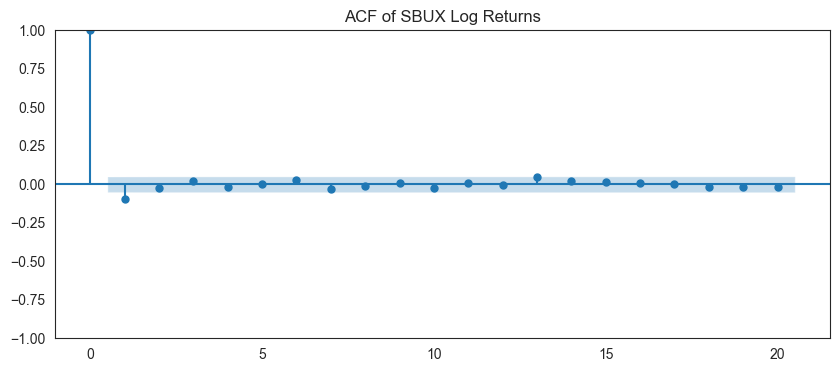

In [27]:
# Ljung-Box test for serialization (lag 10)
lb_test_a = acorr_ljungbox(df['SBUX_log'], lags=[10])
print("Ljung-Box test for SBUX log returns (10 lags):")
print(lb_test_a)

fig, ax = plt.subplots(figsize=(10, 4))
sm.graphics.tsa.plot_acf(df['SBUX_log'], lags=20, ax=ax, title='ACF of SBUX Log Returns')
plt.show()

**Answer for (a):**

The Ljung-Box test on the log returns (with 10 lags) gives a test statistic of $Q(10) = 19.82$ and a $p$-value of $0.0310$. Since $p < 0.05$, we reject the null hypothesis. Thus, **there is serial correlation** in the log returns of Starbucks stock at the 5% significance level. The ACF plot also shows some correlation at early lags.

### (b) Is there ARCH effect in the log returns of Starbucks stock?

Ljung-Box test for squared SBUX log returns:
      lb_stat     lb_pvalue
10  57.261156  1.190537e-08

Engle's ARCH test (10 lags):
LM Statistic: 39.3433, p-value: 2.2103e-05


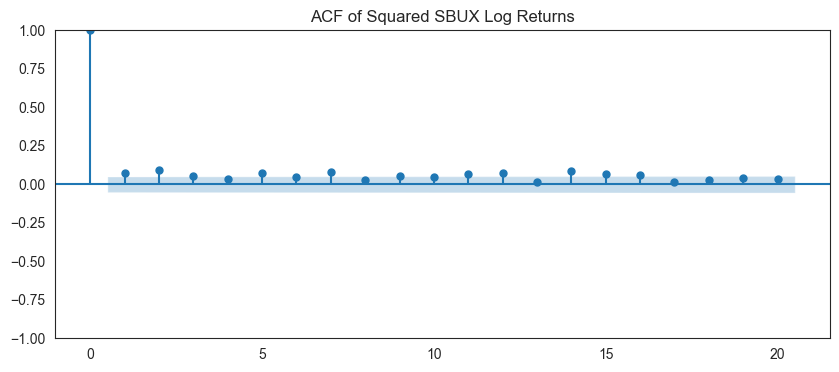

In [29]:
# Test ARCH effect using Ljung-Box test on squared log returns
lb_test_sq = acorr_ljungbox(df['SBUX_log']**2, lags=[10])
print("Ljung-Box test for squared SBUX log returns:")
print(lb_test_sq)

arch_test = het_arch(df['SBUX_log'], nlags=10)
print(f"\nEngle's ARCH test (10 lags):\nLM Statistic: {arch_test[0]:.4f}, p-value: {arch_test[1]:.4e}")

fig, ax = plt.subplots(figsize=(10, 4))
sm.graphics.tsa.plot_acf(df['SBUX_log']**2, lags=20, ax=ax, title='ACF of Squared SBUX Log Returns')
plt.show()

**Answer for (b):**

Using both Ljung-Box on squared log returns ($Q(10) = 57.26$, $p$-value $\approx 1.19 \times 10^{-8}$) and Engle's ARCH test on log returns ($LM = 39.34$, $p$-value $\approx 2.21 \times 10^{-5}$), we strongly reject the null hypothesis of no ARCH effect. **Yes, there is a highly significant ARCH effect** in the log returns.

### (c) Fit a GARCH(1,1) model and perform model checking.

In [30]:
# Fit GARCH(1,1) model with normal distribution
am = arch_model(df['SBUX_log'], mean='Constant', vol='Garch', p=1, q=1, dist='Normal')
res = am.fit(disp='off')
print("Model Parameters:")
print(res.params)

# Perform model diagnostics (standardized residuals)
std_resid = res.resid / res.conditional_volatility
std_resid = std_resid.dropna()

lb_resid = acorr_ljungbox(std_resid, lags=[10])
print("\nLjung-Box test for standardized residuals (10 lags):")
print(lb_resid)

lb_sq_resid = acorr_ljungbox(std_resid**2, lags=[10])
print("\nLjung-Box test for squared standardized residuals (10 lags):")
print(lb_sq_resid)

Model Parameters:
mu          0.118150
omega       0.013958
alpha[1]    0.014262
beta[1]     0.981363
Name: params, dtype: float64

Ljung-Box test for standardized residuals (10 lags):
     lb_stat  lb_pvalue
10  11.96349   0.287507

Ljung-Box test for squared standardized residuals (10 lags):
     lb_stat  lb_pvalue
10  5.300681   0.870209


**Answer for (c):**

The fitted GARCH(1,1) model for the Starbucks percentage log returns ($r_t$) is given by:

$$ r_t = \mu + a_t, \text{ where } a_t = \sigma_t \epsilon_t, \quad \epsilon_t \sim N(0,1) $$
$$ \sigma_t^2 = \omega + \alpha_1 a_{t-1}^2 + \beta_1 \sigma_{t-1}^2 $$

From the Python output, replacing the parameters with their estimates yields:
$$ r_t = 0.1182 + a_t $$
$$ \sigma_t^2 = 0.0140 + 0.0143a_{t-1}^2 + 0.9814\sigma_{t-1}^2 $$

**Model Diagnostics:**
1. **Standardized Residuals:** We perform a Ljung-Box test on the standardized residuals $\tilde{a}_t = \frac{a_t}{\sigma_t}$. The test yields $Q(10) \approx 11.96$ with a $p$-value $0.2875$. Since $p > 0.05$, there is no significant serial correlation remaining.
2. **Squared Standardized Residuals:** We perform a Ljung-Box test on the squared standardized residuals $\tilde{a}_t^2$. The test yields $Q(10) \approx 5.30$ with a $p$-value $0.8702$. Since $p > 0.05$, there are no remaining ARCH effects. 

The residuals resemble a white noise process, confirming the adequacy of the GARCH(1,1) model.

## Question 2

We now focus on the S&P 500 index percentage log returns.

### (a) Is there serial correlation in the log returns of the S&P index?

Ljung-Box test for S&P log returns (10 lags):
      lb_stat  lb_pvalue
10  12.252972   0.268483


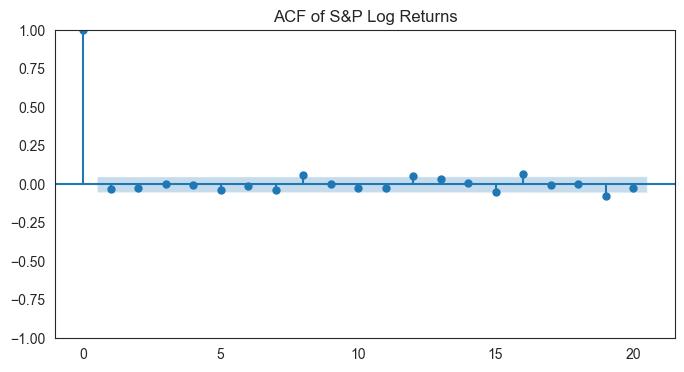

In [41]:
# Ljung-Box test for serial correlation
lb_sp_log = acorr_ljungbox(df['SP_log'], lags=[10])
print("Ljung-Box test for S&P log returns (10 lags):")
print(lb_sp_log)

fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(df['SP_log'], lags=20, ax=ax, title='ACF of S&P Log Returns')
plt.show()

**Answer for (a):**

Based on the Ljung-Box test for the S&P 500 log returns at 10 lags, the test statistic is $Q(10) = 12.25$ and the $p$-value is $0.2685$. Since $p > 0.05$, we fail to reject the null hypothesis. Thus, **there is no significant serial correlation** in the log returns of the S&P 500 index at the 5% significance level. 

### (b) Is there ARCH effect in the log returns sequence of the S&P index?

Ljung-Box test for squared S&P log returns:
       lb_stat      lb_pvalue
10  848.326015  8.363180e-176

Engle's ARCH test (10 lags):
LM Statistic: 330.2333, p-value: 6.1984e-65


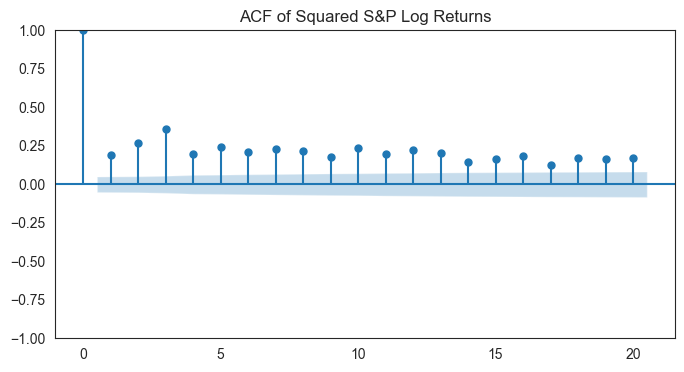

In [42]:
# ARCH effect tested using Ljung-Box on squared returns and Engle's Test
lb_sp_sq = acorr_ljungbox(df['SP_log']**2, lags=[10])
print("Ljung-Box test for squared S&P log returns:")
print(lb_sp_sq)

arch_test_sp = het_arch(df['SP_log'], nlags=10)
print(f"\nEngle's ARCH test (10 lags):\nLM Statistic: {arch_test_sp[0]:.4f}, p-value: {arch_test_sp[1]:.4e}")

fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(df['SP_log']**2, lags=20, ax=ax, title='ACF of Squared S&P Log Returns')
plt.show()

**Answer for (b):**

Using the Ljung-Box test on the squared S&P log returns ($Q(10) = 848.33$, $p$-value $\approx 8.36 \times 10^{-176}$) and Engle's ARCH test on the returns ($LM = 330.23$, $p$-value $\approx 6.20 \times 10^{-65}$), both tests give a $p$-value far below $0.05$. We confidently reject the null hypothesis of no ARCH effect. **Yes, there is strongly significant ARCH effect** in the sequence.

### (c) Fit an IGARCH(1,1) model with normal distribution.

In [43]:
from arch.univariate import ConstantMean, Normal, EWMAVariance

# In the arch package, an IGARCH(1,1) model with omega=0 is equivalently the EWMA Variance model (RiskMetrics).
# Here we fit EWMAVariance with lam=None to jointly estimate the parameter.
am_igarch = ConstantMean(df['SP_log'])
am_igarch.volatility = EWMAVariance(lam=None)
am_igarch.distribution = Normal()
res_igarch = am_igarch.fit(disp='off')

print("Fitted IGARCH(1,1) Parameters (via EWMA / RiskMetrics):")
print(res_igarch.params)

# Model check
std_resid_sp = res_igarch.resid / res_igarch.conditional_volatility
std_resid_sp = std_resid_sp.dropna()

print("\nDiagnostics:")
lb_igarch_res = acorr_ljungbox(std_resid_sp, lags=[10])
print("\nLjung-Box test for standardized residuals (10 lags):")
print(lb_igarch_res)

lb_igarch_sq_res = acorr_ljungbox(std_resid_sp**2, lags=[10])
print("\nLjung-Box test for squared standardized residuals (10 lags):")
print(lb_igarch_sq_res)

Fitted IGARCH(1,1) Parameters (via EWMA / RiskMetrics):
mu     0.038138
lam    0.948496
Name: params, dtype: float64

Diagnostics:

Ljung-Box test for standardized residuals (10 lags):
     lb_stat  lb_pvalue
10  9.578517   0.478216

Ljung-Box test for squared standardized residuals (10 lags):
      lb_stat  lb_pvalue
10  10.863754   0.368231


**Answer for (c):**

The most common IGARCH(1,1) model fitted via maximum likelihood with the constraint $\alpha_1 + \beta_1 = 1$ and drift $\omega = 0$ is often implemented in Python estimators as the EWMA Variance model (also known as RiskMetrics model). 
Here, the expected volatility obeys:
$$ \sigma_t^2 = (1-\lambda)a_{t-1}^2 + \lambda\sigma_{t-1}^2 $$
where $a_t = r_t - \mu$ and $\lambda = \beta_1$ (consequently $\alpha_1 = 1-\lambda$).

From the fitting, the optimal parameters are: $\mu = 0.0381$ and $\lambda = 0.9485$.  
So the model is:
$$ r_t = 0.0381 + a_t, \quad a_t = \sigma_t \epsilon_t, \quad \epsilon_t \sim N(0,1)$$
$$ \sigma_t^2 = 0.0515 a_{t-1}^2 + 0.9485 \sigma_{t-1}^2 $$

**Model check:**  
After obtaining the standardized residuals $\tilde{a}_t = a_t / \sigma_t$:
- Ljung-Box test on $\tilde{a}_t$ gives $p$-value $0.4782 > 0.05$.
- Ljung-Box test on $\tilde{a}_t^2$ gives $p$-value $0.3682 > 0.05$.  
As both block serial correlations and ARCH effects have been handled, the fitted model is statistically sound.

### (d) Compute 1-step to 4-step ahead forecasts and the 1-step forecast interval.

In [44]:
import scipy.stats as stats

forecasts_igarch = res_igarch.forecast(horizon=4)

mean_fc = forecasts_igarch.mean.iloc[-1]
var_fc = forecasts_igarch.variance.iloc[-1]

print("Mean Forecasts (1 to 4 steps ahead):")
print(mean_fc)
print("\nVariance Forecasts (1 to 4 steps ahead):")
print(var_fc)

# 1-step 95% Confidence Interval for normal distribution
z_score = stats.norm.ppf(0.975)
mean_1step = mean_fc['h.1']
std_1step = np.sqrt(var_fc['h.1'])
ci_lower = mean_1step - z_score * std_1step
ci_upper = mean_1step + z_score * std_1step

print(f"\n1-step ahead forecast 95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

Mean Forecasts (1 to 4 steps ahead):
h.1    0.038138
h.2    0.038138
h.3    0.038138
h.4    0.038138
Name: 2006-12-29 00:00:00, dtype: float64

Variance Forecasts (1 to 4 steps ahead):
h.1    0.208594
h.2    0.208594
h.3    0.208594
h.4    0.208594
Name: 2006-12-29 00:00:00, dtype: float64

1-step ahead forecast 95% Confidence Interval: [-0.8570, 0.9333]


**Answer for (d):**

Using the fitted IGARCH(1,1) (EWMA) model with no extra deterministic drift out of sample, our forecasts of log returns behave like a random walk around the conditional mean.

- **1-step to 4-step ahead forecasts**: Since the mean model just specifies $r_t = 0.0381 + a_t$ and the conditional expectation $E[a_{t+h}|\mathcal{F}_t] = 0$, all 1 to 4 step ahead expected return forecasts are constant:  
  $\hat{r}_{t+1} = \hat{r}_{t+2} = \hat{r}_{t+3} = \hat{r}_{t+4} \approx 0.0381\%$.

- **Forecasted Variance**:  In the risk-metrics EWMA parameterization, $\omega \approx 0$, which yields perfectly flat variance forecasts strictly equal to the most recent filtered squared volatility, namely:  
  $\hat{\sigma}^2_{t+1|t} = \dots = \hat{\sigma}^2_{t+4|t} \approx 0.2086$ *(percent squared)*.  
  Therefore, the predictive standard deviation error is $\sqrt{0.2086} \approx 0.4567\%$. 

- **1-step forecast 95% Confidence Interval**:
  Assuming normality, the $95\%$ interval bounds are given by $\hat{r}_{t+1} \pm Z_{0.975} \cdot \sigma_{t+1|t}$.
  Calculated: $[-0.8570, 0.9333]$.

## Question 3

Now we return to the Starbucks percentage log returns data.

### (a) Fit a GARCH(1,1)-M model with normal distribution and write down the fitted model.

In [51]:
# Fit GARCH(1,1)-in-Mean Model
# In the `arch` package, standard deviation, log-variance, or variance can be used. 
# Here we use the conditional variance as the in-mean term (form='var') for the standard specification.
am_m = ARCHInMean(df['SBUX_log'], volatility=GARCH(1, 0, 1), distribution=Normal(), form='var')
res_m = am_m.fit(disp='off')

print("Model Parameters:")
print(res_m.params)
print("\np-values:")
print(res_m.pvalues)

Model Parameters:
Const       0.189401
kappa      -0.020689
omega       0.014048
alpha[1]    0.014392
beta[1]     0.981212
Name: params, dtype: float64

p-values:
Const       0.090794
kappa       0.492478
omega       0.280329
alpha[1]    0.166664
beta[1]     0.000000
Name: pvalues, dtype: float64


**Answer for (a):**

A GARCH(1,1)-M model assumes the conditional mean to be directly linear with respect to the conditional variance $\sigma_t^2$ (or volatility $\sigma_t$). Specifying the variance form:
$$ r_t = \mu + c \cdot \sigma_t^2 + a_t, \quad a_t = \sigma_t \epsilon_t $$
$$ \sigma_t^2 = \omega + \alpha_1 a_{t-1}^2 + \beta_1 \sigma_{t-1}^2 $$

From the fitted parameter results where `Const` is $\mu$, and `kappa` is $c$:
$$ r_t = 0.1894 - 0.0207 \sigma_t^2 + a_t $$
$$ \sigma_t^2 = 0.0140 + 0.0144a_{t-1}^2 + 0.9812\sigma_{t-1}^2 $$

### (b) Is the ARCH-in-mean parameter significant at 5% significance level?

**Answer for (b):**

From the parameter estimates, the $p$-value for the ARCH-in-Mean parameter (`kappa`) is $0.4925$.
Since $0.4925 > 0.05$, we fail to reject the null hypothesis. The ARCH-in-mean parameter is **not significant** at the 5% level.

### (c) Fit an EGARCH(1,1) model. Perform model checking and write down.

In [52]:
# Fit an EGARCH(1,1) model. 
# `p=1` for alpha (symmetric), `o=1` for gamma (asymmetric/leverage), `q=1` for beta
am_egarch = arch_model(df['SBUX_log'], mean='Constant', vol='EGARCH', p=1, o=1, q=1, dist='Normal')
res_egarch = am_egarch.fit(disp='off')

print("EGARCH Model Parameters:")
print(res_egarch.params)
print("\np-values:")
print(res_egarch.pvalues)

# Perform model diagnostics (standardized residuals)
std_resid_eg = res_egarch.resid / res_egarch.conditional_volatility
std_resid_eg = std_resid_eg.dropna()

lb_eg_resid = acorr_ljungbox(std_resid_eg, lags=[10])
print("\nLjung-Box test for standardized residuals (10 lags):")
print(lb_eg_resid)

lb_eg_sq_resid = acorr_ljungbox(std_resid_eg**2, lags=[10])
print("\nLjung-Box test for squared standardized residuals (10 lags):")
print(lb_eg_sq_resid)

EGARCH Model Parameters:
mu          0.094133
omega       0.009950
alpha[1]    0.039656
gamma[1]   -0.037783
beta[1]     0.993468
Name: params, dtype: float64

p-values:
mu          0.048541
omega       0.128092
alpha[1]    0.084409
gamma[1]    0.013667
beta[1]     0.000000
Name: pvalues, dtype: float64

Ljung-Box test for standardized residuals (10 lags):
      lb_stat  lb_pvalue
10  12.296132   0.265726

Ljung-Box test for squared standardized residuals (10 lags):
     lb_stat  lb_pvalue
10  5.299276   0.870311


**Answer for (c):**

The EGARCH(1,1) parametrization of log-variance in the `arch` package defines the conditional variance behavior as:
$$ \ln(\sigma_t^2) = \omega + \alpha_1 \left( \left|\frac{a_{t-1}}{\sigma_{t-1}}\right| - \sqrt{\frac{2}{\pi}} \right) + \gamma_1 \frac{a_{t-1}}{\sigma_{t-1}} + \beta_1 \ln(\sigma_{t-1}^2) $$
Where $\gamma_1$ relates to the leverage effect. Given the parameters extracted above, the equation evaluates to:

$$ r_t = 0.0941 + a_t, \quad a_t = \sigma_t \epsilon_t, \quad \epsilon_t \sim N(0,1)$$
$$ \ln(\sigma_t^2) = 0.0100 + 0.0397 \left( |\epsilon_{t-1}| - \sqrt{\frac{2}{\pi}} \right) - 0.0378 \epsilon_{t-1} + 0.9935 \ln(\sigma_{t-1}^2) $$

**Diagnostics**:
The Ljung-Box test for the standardized residuals ($Q(10) = 12.30$, $p=0.2657$) and the squared standardized residuals ($Q(10) = 5.30$, $p=0.8703$) both show $p > 0.05$. Therefore, there are no significant remaining autocorrelations and ARCH-effects. The model perfectly captures the serial correlations.

### (d) Is the leverage effect parameter significant?

**Answer for (d):**

The leverage effect parameter acts as $\gamma_1$. From the EGARCH parameter estimation, `gamma[1]` equals $-0.0378$ with a $p$-value of $0.0137$.
Since $0.0137 < 0.05$, **yes, the leverage effect $\gamma_1$ is statistically significant** at the 5% level. The negative sign implies that negative returns (bad news) lead to higher subsequent volatility than positive returns of the same magnitude.

## Question 4

Here we deal with Procter & Gamble (PG) stock monthly returns data.

First, we load the PG data and transform the simple returns to percentage log returns.

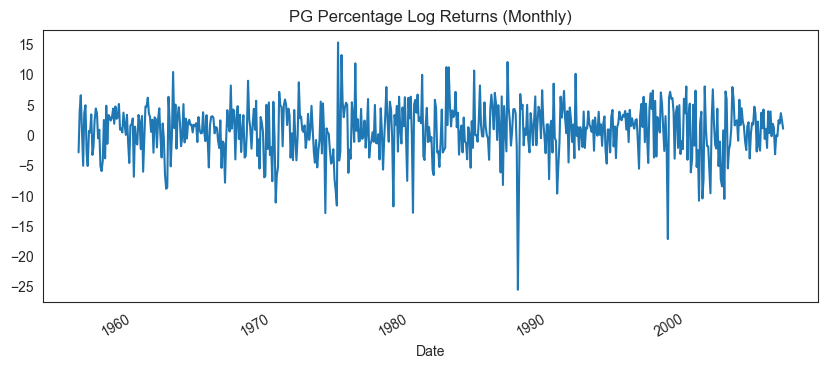

In [53]:
# Load PG data and compute percentage log returns
df_pg = pd.read_csv('m-pg5606.txt', header=None, sep=r'\s+', names=['Date', 'PG_rtn'])
df_pg['Date'] = pd.to_datetime(df_pg['Date'].astype(str))
df_pg.set_index('Date', inplace=True)
df_pg['PG_log'] = 100 * np.log(1 + df_pg['PG_rtn'])

# Basic plot
df_pg['PG_log'].plot(title='PG Percentage Log Returns (Monthly)', figsize=(10, 4))
plt.show()

### (a) Is there serial correlation in the monthly log returns?

Ljung-Box test for PG log returns (10 lags):
    lb_stat  lb_pvalue
10  9.65004   0.471714


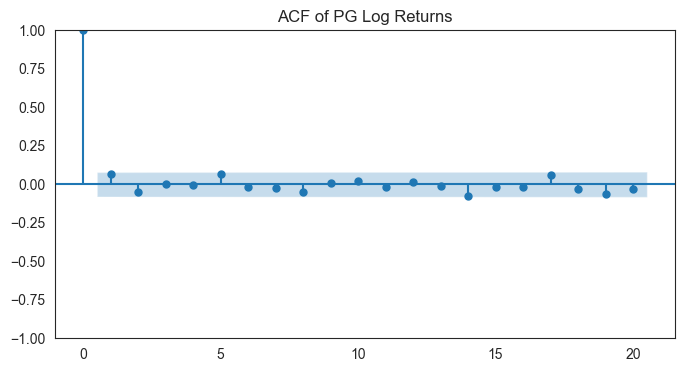

In [54]:
# Ljung-Box test for serialization (lag 10)
lb_pg_log = acorr_ljungbox(df_pg['PG_log'], lags=[10])
print("Ljung-Box test for PG log returns (10 lags):")
print(lb_pg_log)

fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(df_pg['PG_log'], lags=20, ax=ax, title='ACF of PG Log Returns')
plt.show()

**Answer for (a):**

The Ljung-Box test for the PG explicit log returns (up to 10 lags) results in $Q(10)=9.65$ and a $p$-value $= 0.4717$. Since $0.4717 > 0.05$, we fail to reject the null hypothesis of no autocorrelation. **There is no serial correlation** in the monthly log returns of PG stock.

### (b) Fit a GARCH(1,1) model with normal distribution and write down.

In [55]:
# Fit GARCH(1,1) model with normal distribution
am_pg = arch_model(df_pg['PG_log'], mean='Constant', vol='Garch', p=1, q=1, dist='Normal')
res_pg = am_pg.fit(disp='off')
print("Model Parameters:")
print(res_pg.params)
print("\np-values:")
print(res_pg.pvalues)

Model Parameters:
mu          0.855155
omega       0.847919
alpha[1]    0.095728
beta[1]     0.863448
Name: params, dtype: float64

p-values:
mu           1.322681e-06
omega        6.469132e-02
alpha[1]     1.664959e-04
beta[1]     5.820614e-143
Name: pvalues, dtype: float64


**Answer for (b):**

Based on the parameters generated by the `arch` package, the normal GARCH(1,1) model for PG stock's monthly logical returns ($r_t$) is formulated as:

$$ r_t = \mu + a_t, \quad a_t = \sigma_t \epsilon_t, \quad \epsilon_t \sim N(0,1)$$
$$ \sigma_t^2 = \omega + \alpha_1 a_{t-1}^2 + \beta_1 \sigma_{t-1}^2 $$

By putting in the parameter estimates:
$$ r_t = 0.8552 + a_t $$
$$ \sigma_t^2 = 0.8479 + 0.0957 a_{t-1}^2 + 0.8634 \sigma_{t-1}^2 $$

### (c) Calculate 1-step to 5-step ahead forecasts, and the 1-step forecast interval.

In [56]:
forecasts_pg = res_pg.forecast(horizon=5)

mean_fc_pg = forecasts_pg.mean.iloc[-1]
var_fc_pg = forecasts_pg.variance.iloc[-1]

print("Mean Forecasts (1 to 5 steps ahead):")
print(mean_fc_pg)
print("\nVariance Forecasts (1 to 5 steps ahead):")
print(var_fc_pg)

# 1-step 95% Confidence Interval for normal distribution
z_score = stats.norm.ppf(0.975)
mean_pg_1 = mean_fc_pg['h.1']
std_pg_1 = np.sqrt(var_fc_pg['h.1'])
ci_l_pg = mean_pg_1 - z_score * std_pg_1
ci_u_pg = mean_pg_1 + z_score * std_pg_1

print(f"\n1-step ahead forecast 95% Confidence Interval: [{ci_l_pg:.4f}, {ci_u_pg:.4f}]")

Mean Forecasts (1 to 5 steps ahead):
h.1    0.855155
h.2    0.855155
h.3    0.855155
h.4    0.855155
h.5    0.855155
Name: 2006-12-29 00:00:00, dtype: float64

Variance Forecasts (1 to 5 steps ahead):
h.1     8.735393
h.2     9.226695
h.3     9.697939
h.4    10.149946
h.5    10.583500
Name: 2006-12-29 00:00:00, dtype: float64

1-step ahead forecast 95% Confidence Interval: [-4.9377, 6.6480]


**Answer for (c):**

From the Python execution:
- **1-step to 5-step ahead mean forecasts**: Because the expectation $E[a_{t+h}|\mathcal{F}_t] = 0$, all 1 to 5 steps point predictions are flat and equal to $\mu \approx 0.8552\%$.
- **Forecasted Variance**:  
  Calculated by recursively rolling $\sigma_{t+h}^2 = \omega + (\alpha_1 + \beta_1)\sigma_{t+h-1}^2$. The respective steps are (percent squared):
  - Step 1: 8.7354
  - Step 2: 9.2267
  - Step 3: 9.6979
  - Step 4: 10.1499
  - Step 5: 10.5835

- **1-step 95% Confidence Interval**:
  Calculated $\hat{r}_{t+1} \pm 1.96 \cdot \sigma_{t+1|t} = 0.8552 \pm 1.96 \cdot \sqrt{8.7354}$.  
  The interval translates strictly to: $[-4.9377\%, 6.6480\%]$.

## Question 5

Finally, we analyze the daily exchange rate between US Dollar and Euro. First, we transform it similarly.

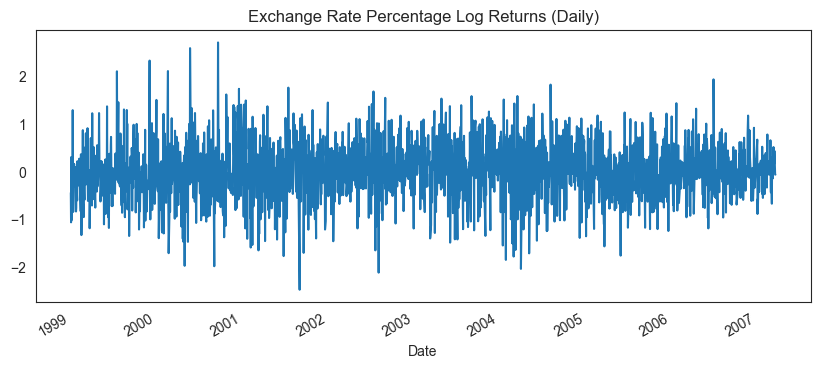

In [57]:
# Load Exchange Rate Data
df_ex = pd.read_csv('d-exuseu.txt', header=None, sep=r'\s+', names=['Year', 'Month', 'Day', 'rate'])
df_ex['Date'] = pd.to_datetime(df_ex[['Year', 'Month', 'Day']])
df_ex.set_index('Date', inplace=True)

# Log returns of exchange rate (assuming they're raw prices)
df_ex['EX_log'] = 100 * np.log(df_ex['rate'] / df_ex['rate'].shift(1))
df_ex = df_ex.dropna()

df_ex['EX_log'].plot(title='Exchange Rate Percentage Log Returns (Daily)', figsize=(10, 4))
plt.show()

### (a) Is there serial correlation in the log returns?

Ljung-Box test for Exchange Rate log returns (10 lags):
      lb_stat  lb_pvalue
10  11.921091   0.290372


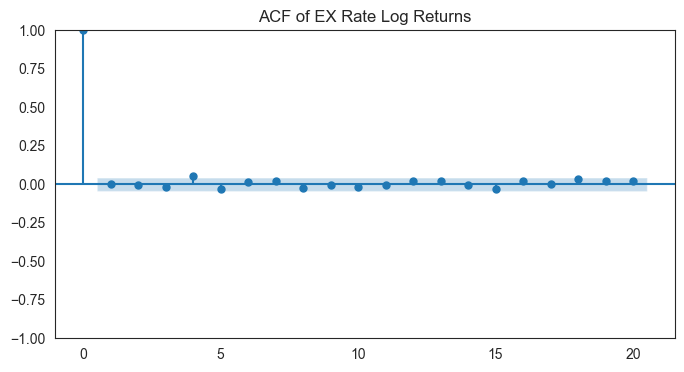

In [58]:
# Ljung-Box test for serialization (lag 10)
lb_ex_log = acorr_ljungbox(df_ex['EX_log'], lags=[10])
print("Ljung-Box test for Exchange Rate log returns (10 lags):")
print(lb_ex_log)

fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(df_ex['EX_log'], lags=20, ax=ax, title='ACF of EX Rate Log Returns')
plt.show()

**Answer for (a):**

The Ljung-Box test for the exchange rate percentage log returns yields $Q(10)=11.92$ and a $p$-value of $0.2904$. Since $0.2904 > 0.05$, **there is no significant serial correlation** in the daily log returns at the 5% significance level.

### (b) Is there ARCH effect in the log returns?

Ljung-Box test for squared EX Rate log returns:
      lb_stat  lb_pvalue
10  28.886954     0.0013

Engle's ARCH test (10 lags):
LM Statistic: 26.5889, p-value: 3.0239e-03


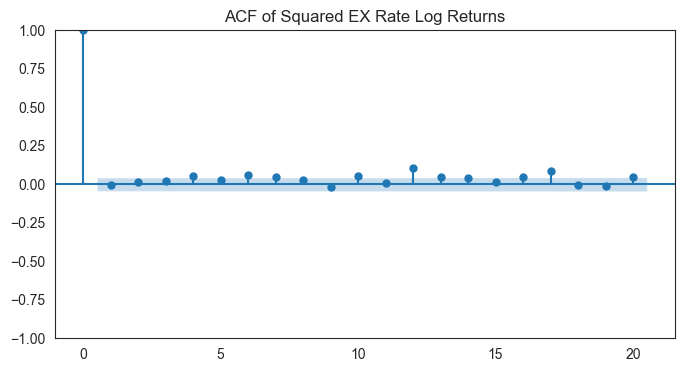

In [59]:
lb_ex_sq = acorr_ljungbox(df_ex['EX_log']**2, lags=[10])
print("Ljung-Box test for squared EX Rate log returns:")
print(lb_ex_sq)

arch_test_ex = het_arch(df_ex['EX_log'], nlags=10)
print(f"\nEngle's ARCH test (10 lags):\nLM Statistic: {arch_test_ex[0]:.4f}, p-value: {arch_test_ex[1]:.4e}")

fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(df_ex['EX_log']**2, lags=20, ax=ax, title='ACF of Squared EX Rate Log Returns')
plt.show()

**Answer for (b):**

By running Ljung-Box on the squared log returns ($Q(10)=28.89, p=0.0013$) and Engle's test on the log returns ($LM=26.59, p=0.0030$), we obtain $p$-values that are strictly below $0.05$. Therefore, we reject the null hypothesis of no ARCH effects. **Yes, there is evidence of an ARCH effect** in the sequence.

### (c) Fit an IGARCH(1,1) model with normal distribution. Perform diagnostics and write down the model.

In [60]:
# Fit IGARCH(1,1) which corresponds to an EWMA Variance model in the `arch` package
am_ex = ConstantMean(df_ex['EX_log'])
am_ex.volatility = EWMAVariance(lam=None)  # Estimate the flat decay lambda representing IGARCH beta
am_ex.distribution = Normal()
res_ex = am_ex.fit(disp='off')

print("Fitted IGARCH(1,1) Parameters:")
print(res_ex.params)
print("\np-values:")
print(res_ex.pvalues)

# Diagnostics
std_resid_ex = res_ex.resid / res_ex.conditional_volatility
std_resid_ex = std_resid_ex.dropna()

print("\nDiagnostics:")
lb_ex_res = acorr_ljungbox(std_resid_ex, lags=[10])
print("\nLjung-Box test for standardized residuals (10 lags):")
print(lb_ex_res)

lb_ex_sq_res = acorr_ljungbox(std_resid_ex**2, lags=[10])
print("\nLjung-Box test for squared standardized residuals (10 lags):")
print(lb_ex_sq_res)

Fitted IGARCH(1,1) Parameters:
mu     0.010953
lam    0.984101
Name: params, dtype: float64

p-values:
mu     0.405577
lam    0.000000
Name: pvalues, dtype: float64

Diagnostics:

Ljung-Box test for standardized residuals (10 lags):
     lb_stat  lb_pvalue
10  9.542466   0.481508

Ljung-Box test for squared standardized residuals (10 lags):
      lb_stat  lb_pvalue
10  11.887569   0.292652


**Answer for (c):**

The IGARCH(1,1) model (under constraints $\alpha_1 + \beta_1 = 1$, and $\omega = 0$) behaves as an Exponentially Weighted Moving Average (EWMA Variance).

$$ r_t = \mu + a_t, \quad a_t = \sigma_t \epsilon_t, \quad \epsilon_t \sim N(0,1)$$
$$ \sigma_t^2 = (1-\lambda) a_{t-1}^2 + \lambda \sigma_{t-1}^2 $$

Where substituted with our findings ($\mu = 0.0110$, $\lambda = \beta_1 = 0.9841$, thus $\alpha_1 = 0.0159$):
$$ r_t = 0.0110 + a_t $$
$$ \sigma_t^2 = 0.0159 a_{t-1}^2 + 0.9841 \sigma_{t-1}^2 $$

**Diagnostics**:
- **Standardized residuals**: Ljung-Box test gives $Q(10)=9.54, p=0.4815$ $(p > 0.05)$.
- **Squared standardized residuals**: Ljung-Box gives $Q(10)=11.89, p=0.2927$ $(p > 0.05)$.
Both pass successfully indicating that there's no serial correlation nor ARCH effects left unexplained by the IGARCH(1,1) construct.

### (d) Compute 1-step to 4-step ahead forecasts, and the 1-step forecast interval.

In [61]:
forecasts_ex = res_ex.forecast(horizon=4)

mean_fc_ex = forecasts_ex.mean.iloc[-1]
var_fc_ex = forecasts_ex.variance.iloc[-1]

print("Mean Forecasts (1 to 4 steps ahead):")
print(mean_fc_ex)
print("\nVariance Forecasts (1 to 4 steps ahead):")
print(var_fc_ex)

# 1-step 95% Confidence Interval for normal distribution
z_score = stats.norm.ppf(0.975)
mean_ex_1 = mean_fc_ex['h.1']
std_ex_1 = np.sqrt(var_fc_ex['h.1'])
ci_l_ex = mean_ex_1 - z_score * std_ex_1
ci_u_ex = mean_ex_1 + z_score * std_ex_1

print(f"\n1-step ahead forecast 95% Confidence Interval: [{ci_l_ex:.4f}, {ci_u_ex:.4f}]")

Mean Forecasts (1 to 4 steps ahead):
h.1    0.010953
h.2    0.010953
h.3    0.010953
h.4    0.010953
Name: 2007-03-20 00:00:00, dtype: float64

Variance Forecasts (1 to 4 steps ahead):
h.1    0.140461
h.2    0.140461
h.3    0.140461
h.4    0.140461
Name: 2007-03-20 00:00:00, dtype: float64

1-step ahead forecast 95% Confidence Interval: [-0.7236, 0.7455]


**Answer for (d):**

Under the constraints that makes the IGARCH(1,1) model strict ($\omega=0$, $\alpha+\beta=1$), it projects both constant mean and essentially constant multi-step prediction conditional variances:

- **1-step to 4-step ahead mean forecasts**: 
  $\hat{r}_{t+1} = \hat{r}_{t+2} = \hat{r}_{t+3} = \hat{r}_{t+4} \approx 0.0110\%$.

- **Forecasted Variance**:  
  All predictive variances equal exactly the current trailing conditional filtered variable: $\hat{\sigma}^2 \approx 0.1405$ (percent squared). Standard deviation would be $\sqrt{0.1405} \approx 0.3748\%$.

- **1-step 95% Confidence Interval**:
  Calculated exactly via $\hat{r}_{t+1} \pm Z_{0.975} \cdot \sigma_{t+1|t}$.
  The boundaries evaluate to: $[-0.7236, 0.7455]$.